## I. Data Exploration

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Gold Price.csv to Gold Price.csv


In [3]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping

### Load Dataset

In [4]:
# Load the dataset
df = pd.read_csv("Gold Price.csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (3104, 7)


### Dataset Overview & Summary Statistics

In [5]:
print("= DATASET OVERVIEW =")
print("\nFirst 5 rows:")
print(df.head())

= DATASET OVERVIEW =

First 5 rows:
         Date   Price    Open    High     Low  Volume  Chg%
0  2026-01-02  135793  136143  137037  135525   51877  0.02
1  2026-01-01  135771  135687  135850  135001   14622  0.23
2  2025-12-31  135454  136526  136527  134866   59050  1.10
3  2025-12-30  133974  133185  134880  132853   36733  1.04
4  2025-12-29  132595  137628  138269  131695   90640 -3.77


In [6]:
print("\nColumn names and data types:")
print(df.info())


Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB
None


In [7]:
print("\n=== SUMMARY STATISTICS ===")
print(df.describe())


=== SUMMARY STATISTICS ===
               Price           Open           High            Low  \
count    3104.000000    3104.000000    3104.000000    3104.000000   
mean    46263.721972   46250.184278   46515.665271   45997.234214   
std     22230.385519   22191.261855   22364.944669   22053.596236   
min     24545.000000   24583.000000   24635.000000   24470.000000   
25%     29358.750000   29331.500000   29462.750000   29214.000000   
50%     38832.500000   38902.500000   39083.000000   38626.500000   
75%     54970.250000   54900.000000   55211.250000   54730.500000   
max    137789.000000  137628.000000  138300.000000  136300.000000   

              Volume         Chg%  
count    3104.000000  3104.000000  
mean    14855.159472     0.052957  
std     14197.123722     0.854364  
min         0.000000    -5.980000  
25%      6780.000000    -0.370000  
50%     11520.000000     0.060000  
75%     18602.500000     0.480000  
max    149474.000000     5.300000  


### Convert Date and Sort Chronologically


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2014-01-01,29542,29435,29598,29340,2930,0.25
1,2014-01-02,29975,29678,30050,29678,3140,1.47
2,2014-01-03,29727,30031,30125,29539,3050,-0.83
3,2014-01-04,29279,29279,29279,29279,0,-1.51
4,2014-01-06,29119,29300,29395,29051,24380,-0.55


### Missing Values Analysis

In [9]:
# List number and percentage of missing values per variable
print("=== MISSING VALUES ANALYSIS ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_info[missing_info['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 8))
missing_plot_data = missing_info[missing_info['Missing Count'] > 0]
if not missing_plot_data.empty:
    plt.bar(missing_plot_data.index, missing_plot_data['Missing Percentage'])
    plt.title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Percentage Missing (%)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

=== MISSING VALUES ANALYSIS ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


<Figure size 1000x800 with 0 Axes>

## II. Data Visualization

### Visualize Gold Price Trend

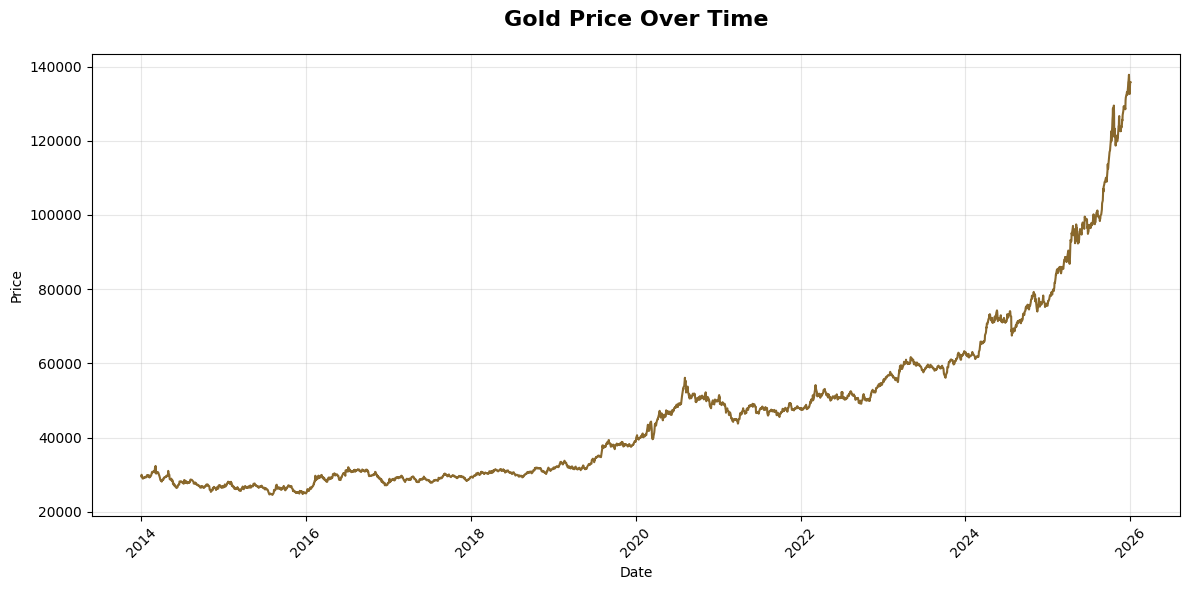

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], color='#89682c')

plt.title("Gold Price Over Time", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Rolling Mean (Trend Smoothing)

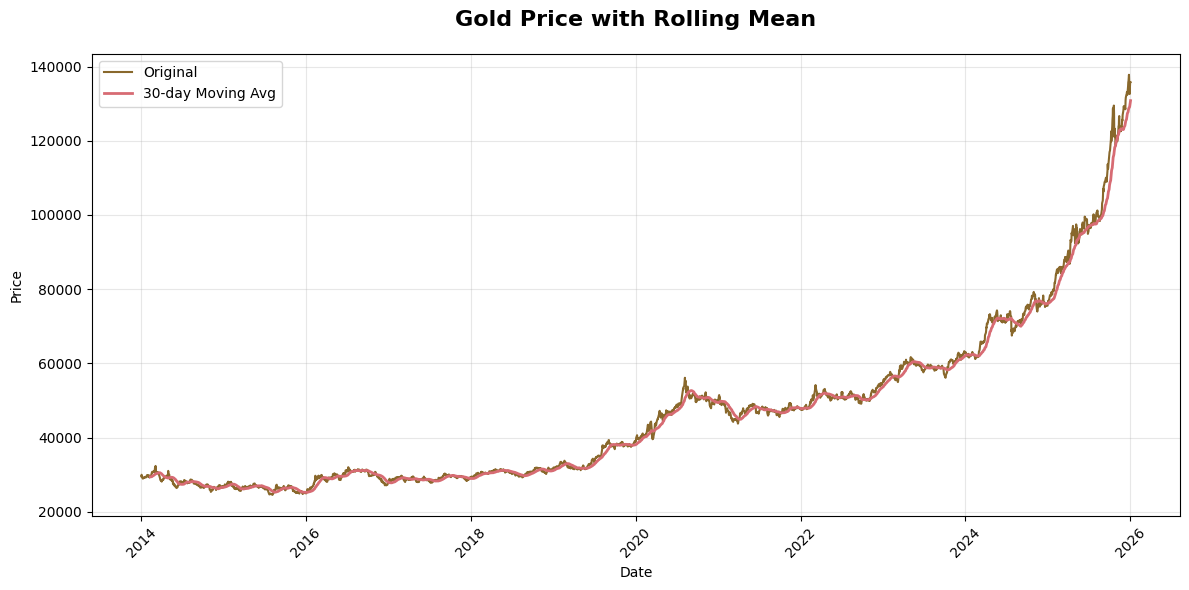

In [11]:
# Shows long-term trend by removing noise
df['Rolling_30'] = df['Price'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label='Original', color='#89682c')
plt.plot(df['Date'], df['Rolling_30'], label='30-day Moving Avg', linewidth=2, color='#d76b73')
plt.legend()
plt.title("Gold Price with Rolling Mean", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Distribution Comparison

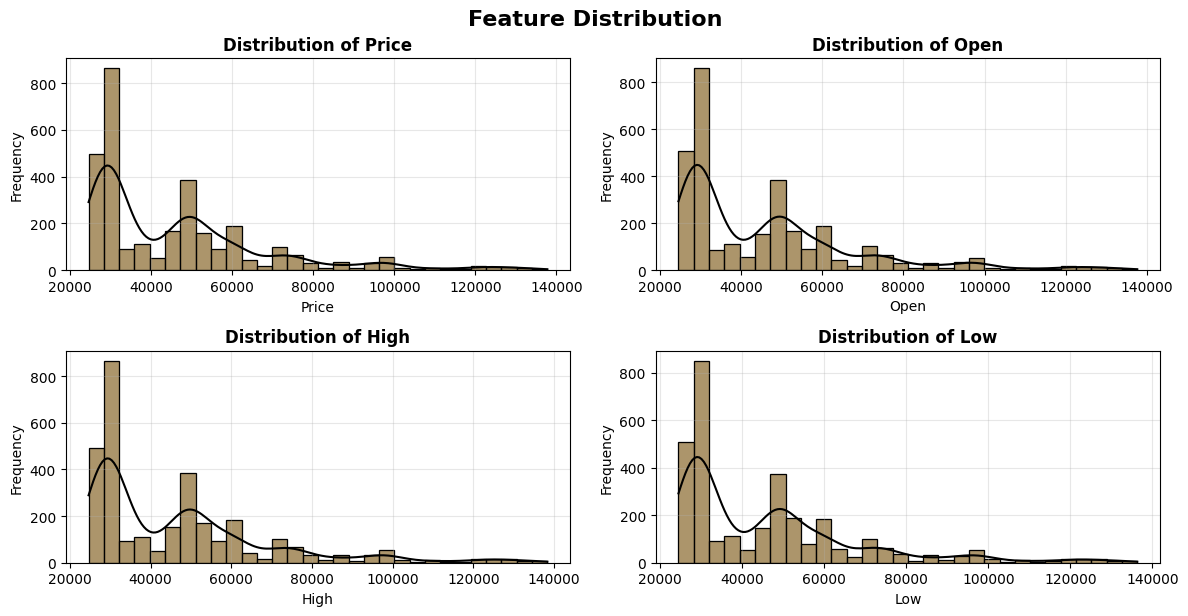

In [12]:
# Histograms for the distribution of all features
plot_features = ['Price','Open','High','Low']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.ravel()

for i, col in enumerate(plot_features):
    ax = axes[i]
    sns.histplot(df[col],
                 bins=30,
                 kde=True,
                 ax=ax,
                 color='#89682c',
                 edgecolor='black',
                 alpha=0.7)
    if ax.lines:
        ax.lines[-1].set_color('black')
        ax.lines[-1].set_linewidth(1.5)

    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Feature Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.show()

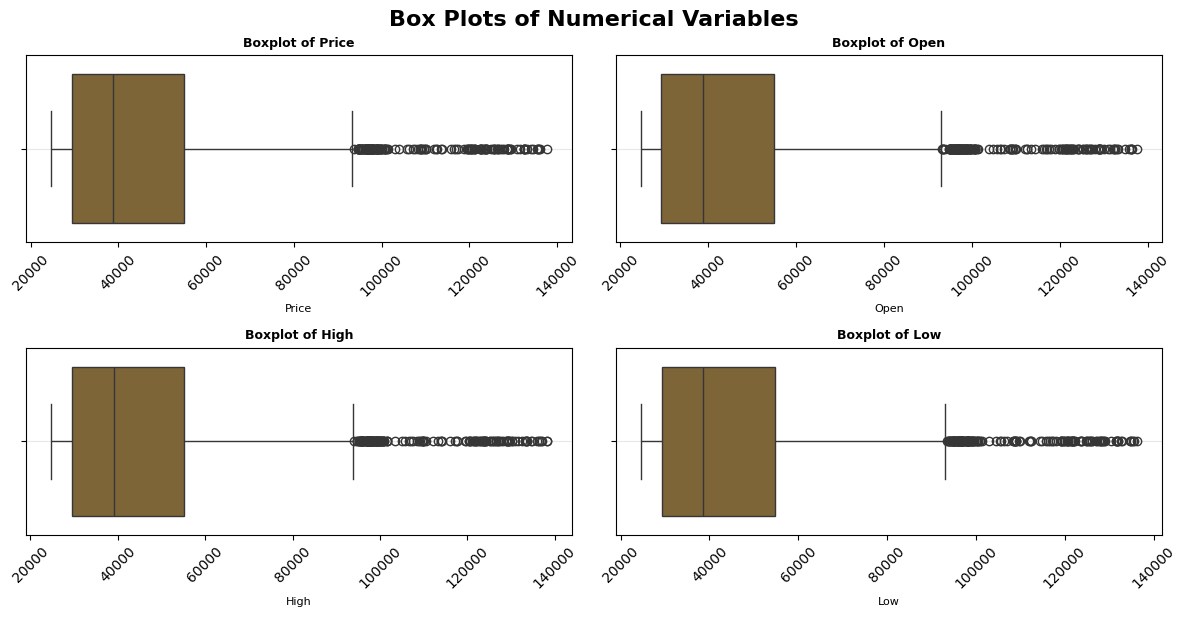

In [13]:
# Boxplot for distribution of all features

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.ravel()

for i, col in enumerate(plot_features):
    sns.boxplot(
        data=df,
        x=col,
        color='#89682c',
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot of {col}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### Correlation Heatmap

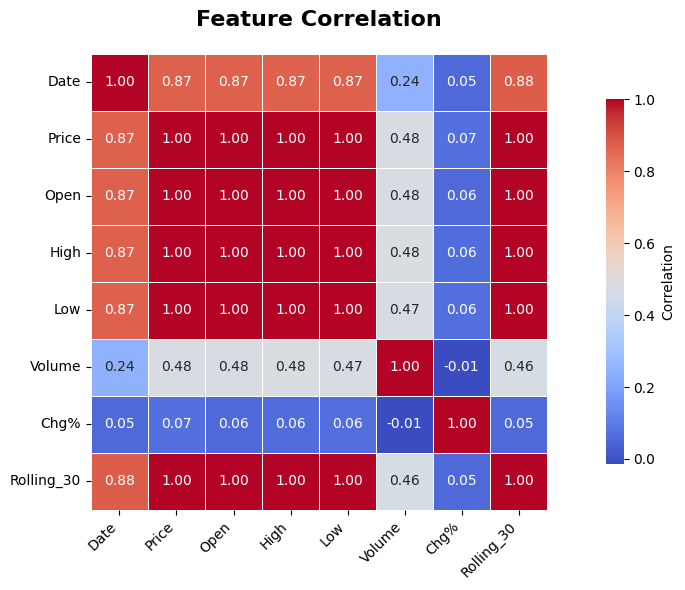

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(
    df.corr(), annot=True,
    cmap='coolwarm', # blue = negative, red = positive
    square=True, fmt=".2f",
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlation"})

plt.title("Feature Correlation", fontsize=16, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
# Find high correlations
print("\n High Correlations (|r| > 0.7):")
corr_matrix = df.corr()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")


 High Correlations (|r| > 0.7):
  Date <-> Price: 0.872
  Date <-> Open: 0.872
  Date <-> High: 0.871
  Date <-> Low: 0.873
  Date <-> Rolling_30: 0.880
  Price <-> Open: 1.000
  Price <-> High: 1.000
  Price <-> Low: 1.000
  Price <-> Rolling_30: 0.998
  Open <-> High: 1.000
  Open <-> Low: 1.000
  Open <-> Rolling_30: 0.998
  High <-> Low: 1.000
  High <-> Rolling_30: 0.998
  Low <-> Rolling_30: 0.998


### Scatter Plots (Feature Relationships)

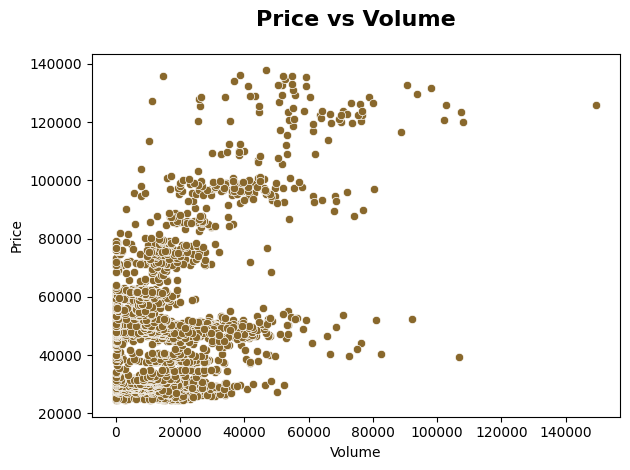

In [16]:
sns.scatterplot(x=df['Volume'], y=df['Price'], color='#89682c')
plt.title("Price vs Volume", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### Monthly Trend (Seasonality Check)

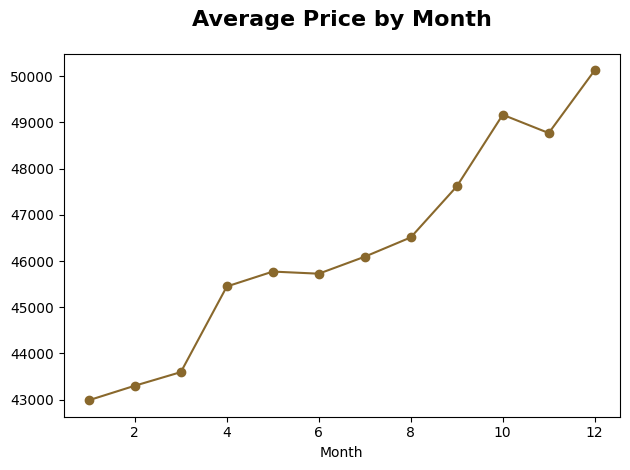

In [17]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Price'].mean()

monthly_avg.plot(kind='line', marker='o', color='#89682c')
plt.title("Average Price by Month", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## III. Data Preprocessing

### Feature Selection

In [18]:
# features_A = ['Price']
features = ['Price', 'Open', 'High', 'Low', 'Volume', 'Chg%']

target_col = 'Price'

data = df[features].copy()
data.head()
# Date is not numerical, no causal meaning
# Exclude Date as it is used to sort the dataset chronologically and to construct time-dependent sequences

,Price,Open,High,Low,Volume,Chg%
0,29542,29435,29598,29340,2930,0.25
1,29975,29678,30050,29678,3140,1.47
2,29727,30031,30125,29539,3050,-0.83
3,29279,29279,29279,29279,0,-1.51
4,29119,29300,29395,29051,24380,-0.55


### Data Partitioning - Time Series

In [19]:
# Split data set into 80% training and 20% test set
train_size = int(len(data) * 0.8)

train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print(f"Training set: {train_data.shape[0]} samples")
print(f"Test set: {test_data.shape[0]} samples")
print(f"Number of features: {train_data.shape[1]}")

Training set: 2483 samples
Test set: 621 samples
Number of features: 6


### Scaling Using MinMaxScaler

In [20]:
# Use MinMaxScaler which is better for deep learning models
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

### Create Sequences (FOR DEEP MODELS)

In [21]:
# This should be aligned with all deep learning models and cannot be changed
LOOKBACK = 30
TARGET_INDEX = 0  # Price is the first column in data

In [22]:
# Convert time series into supervised learning format
def create_sequences(data_array, lookback, target_index=0):
    X, y = [], []
    for i in range(lookback, len(data_array)):
        X.append(data_array[i-lookback:i])
        y.append(data_array[i, target_index])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(train_scaled, LOOKBACK, TARGET_INDEX)
X_test_seq, y_test_seq = create_sequences(test_scaled, LOOKBACK, TARGET_INDEX)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (2453, 30, 6)
y_train_seq: (2453,)
X_test_seq: (591, 30, 6)
y_test_seq: (591,)


### Prepare Data for Linear Regression and ANN

In [23]:
# Flatten sequences for Linear Regression and ANN
X_train_lr = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_lr = X_test_seq.reshape(X_test_seq.shape[0], -1)

print("X_train_flat:", X_train_lr.shape)
print("X_test_flat:", X_test_lr.shape)

X_train_flat: (2453, 180)
X_test_flat: (591, 180)


## IV. Evaluation Functions

### Evaluation Metrics

In [24]:
# Define evaluation metrics
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{name} Performance Metrics:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

### Inverse Scaling Function

In [25]:
# After prediction, we need to inverse the predicted price to actual price so that results are interpretable
def inverse_transform_predictions(y_scaled, scaler, n_features):
    temp = np.zeros((len(y_scaled), n_features))
    temp[:, 0] = y_scaled.reshape(-1)
    return scaler.inverse_transform(temp)[:, 0]

In [26]:
# Convert Test Values Back to Original Scale
n_features = train_scaled.shape[1]
y_test_actual = inverse_transform_predictions(y_test_seq, scaler, n_features)

## V. Model Selection

### Model 1: Linear Regression

In [27]:
# Define and Train LR model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_seq)

#Prediction
lr_pred_scaled = lr_model.predict(X_test_lr)
lr_pred = inverse_transform_predictions(lr_pred_scaled, scaler, n_features)

#Results
lr_results = evaluate_model(y_test_actual, lr_pred, "Linear Regression")

Linear Regression Performance Metrics:
MAE  : 611.7247
RMSE : 916.9376
R2   : 0.9980
MAPE : 0.70%


### Model 2: ANN (MLP)

In [28]:
# Define the ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_lr.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Train ANN
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history_ann = ann_model.fit(
    X_train_lr, y_train_seq,
    validation_split=0.1,
    epochs=50, # This should be consistent as much as possible through all models
    batch_size=32, # This should be consistent as much as possible through all models
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0134 - val_loss: 0.0140
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0171
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - val_loss: 0.0567
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0258
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - val_loss: 0.0251
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - val_loss: 0.0318
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 0.0237
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 0.0476
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - val_loss: 0.0379
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9910e-04 - val_loss: 0.0423
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7052e-04 - val_loss: 0.0348


In [30]:
# Prediction
ann_pred_scaled = ann_model.predict(X_test_lr, verbose=0)
ann_pred = inverse_transform_predictions(ann_pred_scaled, scaler, n_features)

# Result
ann_results = evaluate_model(y_test_actual, ann_pred, "ANN")

ANN Performance Metrics:
MAE  : 8543.7027
RMSE : 9150.9406
R2   : 0.7992
MAPE : 10.33%


### Model 3: GRU

In [31]:
# Define the GRU model
gru_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

In [32]:
#Train the model
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.0074 - val_loss: 4.0147e-04
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0017 - val_loss: 2.0333e-04
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0013 - val_loss: 1.5197e-04
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 9.9021e-04 - val_loss: 0.0014
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 9.1129e-04 - val_loss: 0.0035
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 7.5799e-04 - val_loss: 6.5326e-04
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 6.2854e-04 - val_loss: 0.0038
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 6.2784e-04 - val_loss: 0.0013
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 6.3223e-04 - val_loss: 0.0040
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.9432e-04 - val_loss: 0.0048
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.4194e-04 - val_loss: 0.0034
Epoch 12/50
69/

In [33]:
#Prediction
gru_pred_scaled = gru_model.predict(X_test_seq)
gru_pred = inverse_transform_predictions(gru_pred_scaled, scaler, n_features)

#Result
gru_results = evaluate_model(y_test_actual, gru_pred, "GRU")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
GRU Performance Metrics:
MAE  : 3461.1102
RMSE : 5573.7921
R2   : 0.9255
MAPE : 3.37%


### Model 4: Bi-GRU

In [34]:
#Define the Bi-GRU model
bigru_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Bidirectional(GRU(64)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

bigru_model.compile(optimizer='adam', loss='mse')

In [35]:
#Train the model
history_bigru = bigru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0186 - val_loss: 0.0014
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0015 - val_loss: 8.7598e-04
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0012 - val_loss: 7.5276e-04
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.0641e-04 - val_loss: 0.0019
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 8.6960e-04 - val_loss: 7.6368e-04
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.6936e-04 - val_loss: 8.3108e-04
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.6006e-04 - val_loss: 0.0015
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.1858e-04 - val_loss: 8.1273e-04
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 6.1617e-04 - val_loss: 4.8800e-04


In [36]:
#Prediction
bigru_pred_scaled = bigru_model.predict(X_test_seq)
bigru_pred = inverse_transform_predictions(bigru_pred_scaled, scaler, n_features)

#Results
bigru_results = evaluate_model(y_test_actual, bigru_pred, "Bi-GRU")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Bi-GRU Performance Metrics:
MAE  : 5898.9919
RMSE : 8168.6700
R2   : 0.8400
MAPE : 6.13%


### Model 5: LSTM

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
# Model 5: LSTM

# Define the LSTM model
lstm_model = Sequential([
    LSTM(16, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(8),
    Dense(1)
])

# Compile model
lstm_model.compile(optimizer='adam', loss='mse')

# Train model
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,      # keep consistent with ANN
    batch_size=32,  # keep consistent with ANN
    callbacks=[early_stop],
    verbose=1
)

# Prediction
lstm_pred_scaled = lstm_model.predict(X_test_seq)
lstm_pred = inverse_transform_predictions(lstm_pred_scaled, scaler, n_features)

# Results
lstm_results = evaluate_model(y_test_actual, lstm_pred, "LSTM")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0612 - val_loss: 0.0235
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 8.1974e-04 - val_loss: 0.0195
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 5.6726e-04 - val_loss: 0.0153
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.1907e-04 - val_loss: 0.0149
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.8114e-04 - val_loss: 0.0123
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.5634e-04 - val_loss: 0.0105
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.1974e-04 - val_loss: 0.0096
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.8011e-04 - val_loss: 0.0080
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 3.6938e-04 - val_loss: 0.0067
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.3989e-04 - val_loss: 0.0060
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.1179e-04 - val_loss: 0.0055
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━

### Model 6: Bi-LSTM

In [39]:
# Model 6: Bi-LSTM

from tensorflow.keras.layers import Bidirectional

In [40]:
# Define the Bi-LSTM model
bilstm_model = Sequential([
    Bidirectional(LSTM(16, return_sequences=True), input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Bidirectional(LSTM(8)),
    Dense(1)
])

# Compile model
bilstm_model.compile(optimizer='adam', loss='mse')

# Train model
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history_bilstm = bilstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Prediction
bilstm_pred_scaled = bilstm_model.predict(X_test_seq)
bilstm_pred = inverse_transform_predictions(bilstm_pred_scaled, scaler, n_features)

# Results
bilstm_results = evaluate_model(y_test_actual, bilstm_pred, "Bi-LSTM")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 0.0019 - val_loss: 0.0083
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.9621e-04 - val_loss: 0.0082
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 5.0105e-04 - val_loss: 0.0077
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 4.1149e-04 - val_loss: 0.0056
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 3.3589e-04 - val_loss: 0.0056
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 2.9357e-04 - val_loss: 0.0032
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.3159e-04 - val_loss: 0.0031
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.7938e-04 - val_loss: 0.0026
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.5550e-04 - val_loss: 0.0041
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.8851e-04 - val_loss: 0.0025
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.4250e-04 - val_loss: 0.0016
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━

### Model 7: CNN

In [41]:
# uses Conv1D instead of Conv2D since the input is a 1D time series, not an image
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2, strides=2),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.summary()
print(cnn_model.output_shape)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,241 (149.38 KB)

 Trainable params: 38,241 (149.38 KB)

 Non-trainable params: 0 (0.00 B)

(None, 1)


In [42]:
# fit the model on the training sequences
history_cnn = cnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=50, batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop], verbose=1
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0055 - mae: 0.0411 - val_loss: 0.0205 - val_mae: 0.1090
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7562e-04 - mae: 0.0195 - val_loss: 0.0065 - val_mae: 0.0541
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.9189e-04 - mae: 0.0163 - val_loss: 0.0053 - val_mae: 0.0491
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.2711e-04 - mae: 0.0133 - val_loss: 0.0118 - val_mae: 0.0871
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.9665e-04 - mae: 0.0126 - val_loss: 0.0044 - val_mae: 0.0452
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5619e-04 - mae: 0.0115 - val_loss: 0.0033 - val_mae: 0.0391
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0617e-04 - mae: 0.0103 - val_loss: 0.0029 - val_mae: 0.0368
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5700e-04 - mae: 0.0091 - val_loss: 0.0017 - val_mae: 0.0289
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

In [43]:
# generate predictions, inverse transform to original price scale, and evaluate
loss_cnn, mae_cnn = cnn_model.evaluate(X_test_seq, y_test_seq)
print(f"Test Loss : {loss_cnn:.6f}")
print(f"Test MAE  : {mae_cnn:.6f}")

cnn_pred_scaled = cnn_model.predict(X_test_seq)
cnn_pred        = inverse_transform_predictions(cnn_pred_scaled, scaler, n_features)
cnn_results     = evaluate_model(y_test_actual, cnn_pred, "CNN")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0205 - mae: 0.1090 
Test Loss : 0.020494
Test MAE  : 0.108965
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
CNN Performance Metrics:
MAE  : 4046.7381
RMSE : 5316.5449
R2   : 0.9322
MAPE : 4.41%


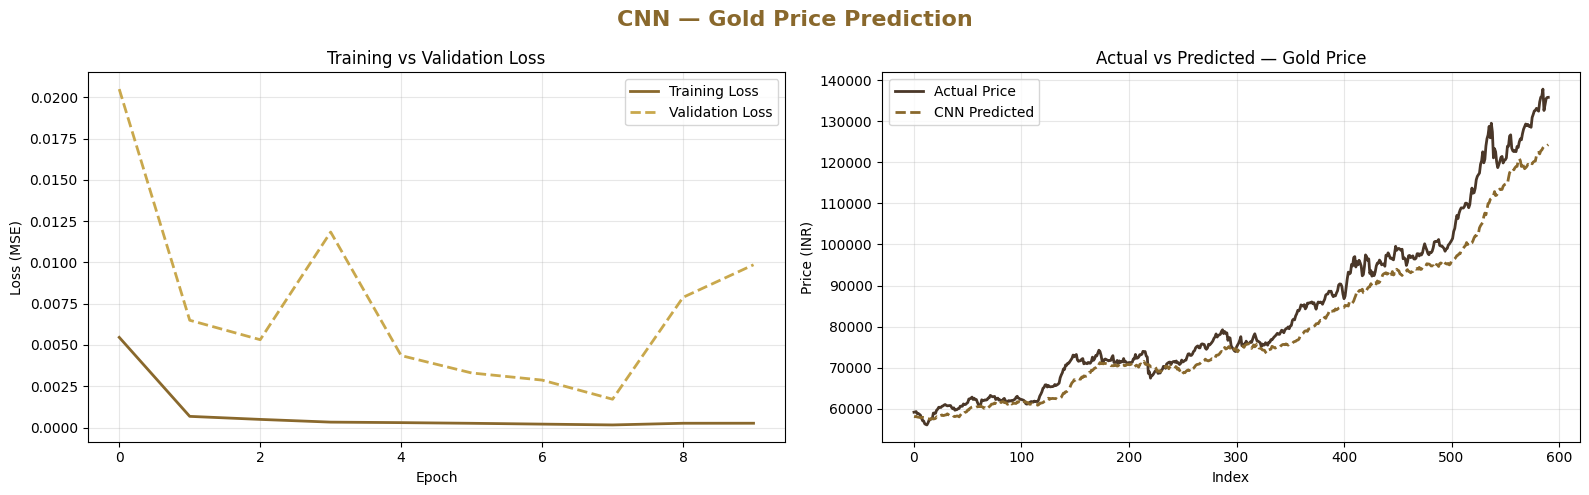

In [82]:
# visualize training dynamics and prediction quality
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('CNN — Gold Price Prediction', fontsize=16, fontweight='bold', color='#89682c')

axes[0].plot(history_cnn.history['loss'],     color='#89682c', linewidth=2, label='Training Loss')
axes[0].plot(history_cnn.history['val_loss'], color='#c9a84c', linewidth=2, linestyle='--', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_test_actual, color='#4a3728', linewidth=2, label='Actual Price')
axes[1].plot(cnn_pred,      color='#89682c', linewidth=2, linestyle='--', label='CNN Predicted')
axes[1].set_title('Actual vs Predicted — Gold Price')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Price (INR)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

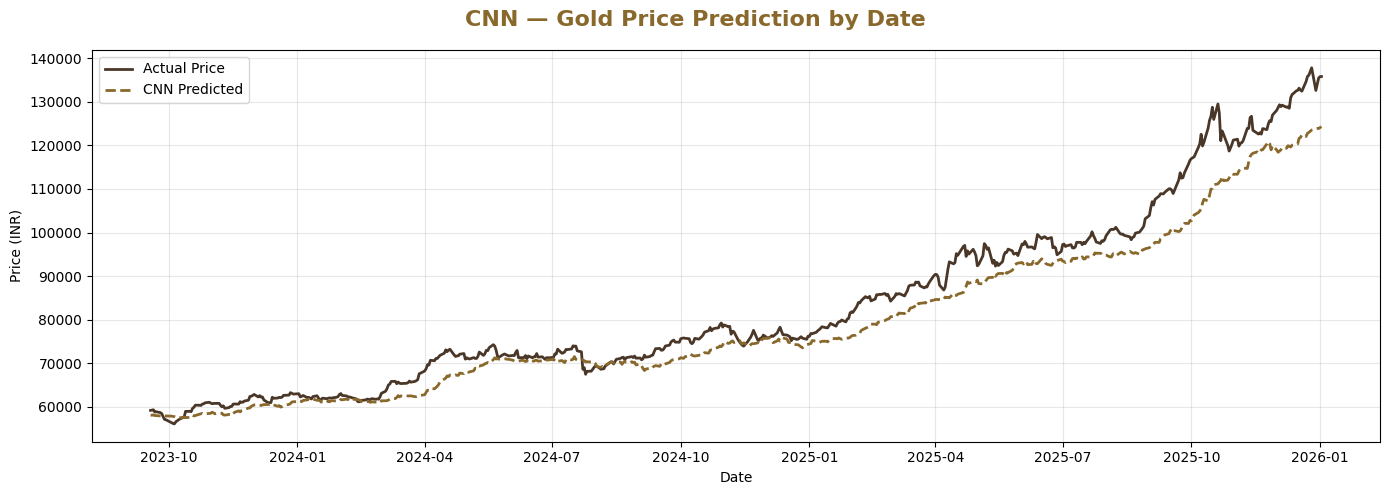

In [81]:
# visualize predictions against real dates
test_dates = df['Date'].iloc[-len(y_test_actual):]

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('CNN — Gold Price Prediction by Date', fontsize=16, fontweight='bold', color='#89682c')

ax.plot(test_dates, y_test_actual, color='#4a3728', linewidth=2, label='Actual Price')
ax.plot(test_dates, cnn_pred,      color='#89682c', linewidth=2, linestyle='--', label='CNN Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Price (INR)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Model 8: Autoencoder

In [46]:
# Dense layers instead of Conv2D since the input is a 1D sequence, not an image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input as KInput, Reshape

def encoder(inputs):
    x = Flatten()(inputs)
    x = Dense(128, activation='relu')(x)
    x = Dense(32,  activation='relu')(x)
    return x

def decoder(latent_vars):
    x = Dense(128, activation='relu')(latent_vars)
    x = Dense(X_train_seq.shape[1] * X_train_seq.shape[2], activation='linear')(x)
    x = Reshape((X_train_seq.shape[1], X_train_seq.shape[2]))(x)
    return x
# connect encoder and decoder into a single autoencoder model
ae_input      = KInput(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
latent_vars   = encoder(ae_input)
reconstructed = decoder(latent_vars)

autoencoder_model = Model(ae_input, reconstructed)
autoencoder_model.compile(optimizer='adam', loss='mse')
autoencoder_model.summary()
print(autoencoder_model.output_shape)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 30, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        23,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 180)            │        23,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 30, 6)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,740 (213.83 KB)

 Trainable params: 54,740 (213.83 KB)

 Non-trainable params: 0 (0.00 B)

(None, 30, 6)


In [47]:
# input = target — the model learns to reconstruct the sequence
# mse instead of binary_crossentropy since values are prices, not pixel probabilities
history_ae = autoencoder_model.fit(
    X_train_seq, X_train_seq,
    epochs=50, batch_size=32,
    validation_data=(X_test_seq, X_test_seq),
    callbacks=[early_stop], verbose=1
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0354 - val_loss: 0.0408
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - val_loss: 0.0241
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0234
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025 - val_loss: 0.0201
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 0.0185
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022 - val_loss: 0.0180
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - val_loss: 0.0175
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - val_loss: 0.0150
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0138
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0135


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0408
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Reconstruction Loss: 0.040800


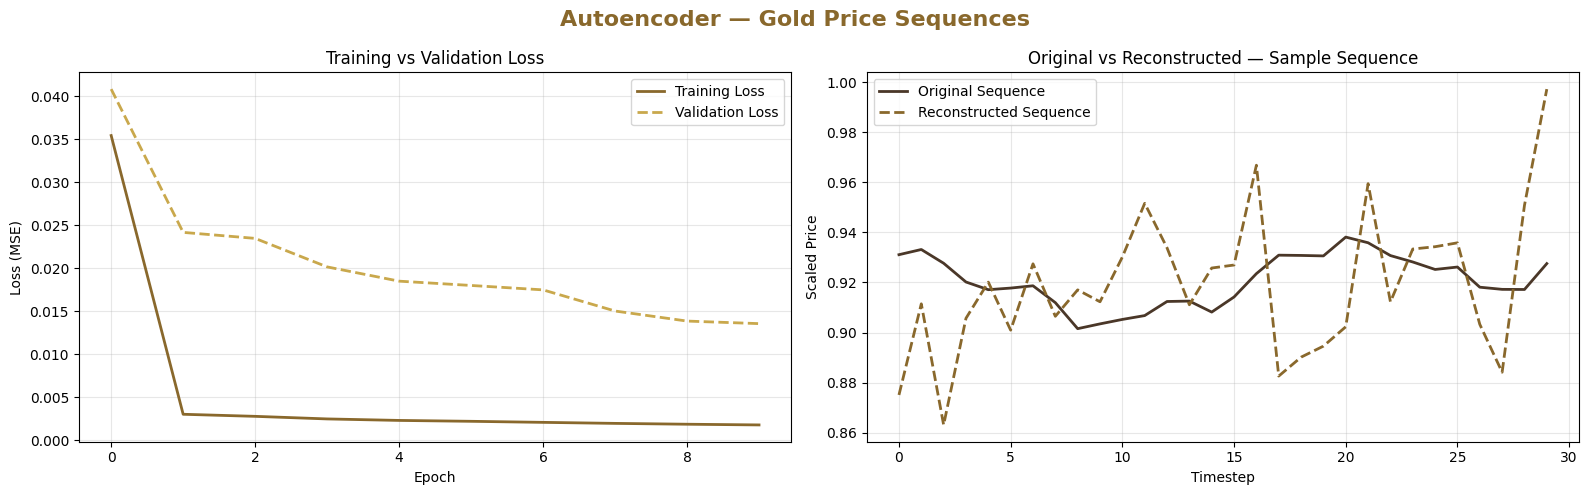

In [80]:
# evaluate reconstruction quality and visualize
loss_ae              = autoencoder_model.evaluate(X_test_seq, X_test_seq)
sample_reconstructed = autoencoder_model.predict(X_test_seq[0:1])[0, :, 0]
print(f"Reconstruction Loss: {loss_ae:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Autoencoder — Gold Price Sequences', fontsize=16, fontweight='bold', color='#89682c')

axes[0].plot(history_ae.history['loss'],     color='#89682c', linewidth=2, label='Training Loss')
axes[0].plot(history_ae.history['val_loss'], color='#c9a84c', linewidth=2, linestyle='--', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(X_test_seq[0, :, 0],  color='#4a3728', linewidth=2, label='Original Sequence')
axes[1].plot(sample_reconstructed,  color='#89682c', linewidth=2, linestyle='--', label='Reconstructed Sequence')
axes[1].set_title('Original vs Reconstructed — Sample Sequence')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Scaled Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# extract the encoder output (bottleneck) and train a prediction head on top of it
encoder_model   = Model(inputs=ae_input, outputs=latent_vars)
X_train_encoded = encoder_model.predict(X_train_seq)
X_test_encoded  = encoder_model.predict(X_test_seq)

ae_pred_head = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dense(1)
])
ae_pred_head.compile(optimizer='adam', loss='mse')
ae_pred_head.fit(
    X_train_encoded, y_train_seq,
    epochs=50, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop], verbose=1
)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0673 - val_loss: 0.0076
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0037
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015 - val_loss: 0.0026
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013 - val_loss: 0.0030
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - val_loss: 0.0026


In [50]:
# generate predictions, inverse transform to original price scale, and evaluate
loss_ae_head = ae_pred_head.evaluate(X_test_encoded, y_test_seq)
print(f"Test Loss : {loss_ae_head:.6f}")

ae_pred_scaled = ae_pred_head.predict(X_test_encoded)
ae_pred        = inverse_transform_predictions(ae_pred_scaled, scaler, n_features)
ae_results     = evaluate_model(y_test_actual, ae_pred, "Autoencoder")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0559 
Test Loss : 0.055862
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Autoencoder Performance Metrics:
MAE  : 7439.7823
RMSE : 8777.5827
R2   : 0.8153
MAPE : 8.36%


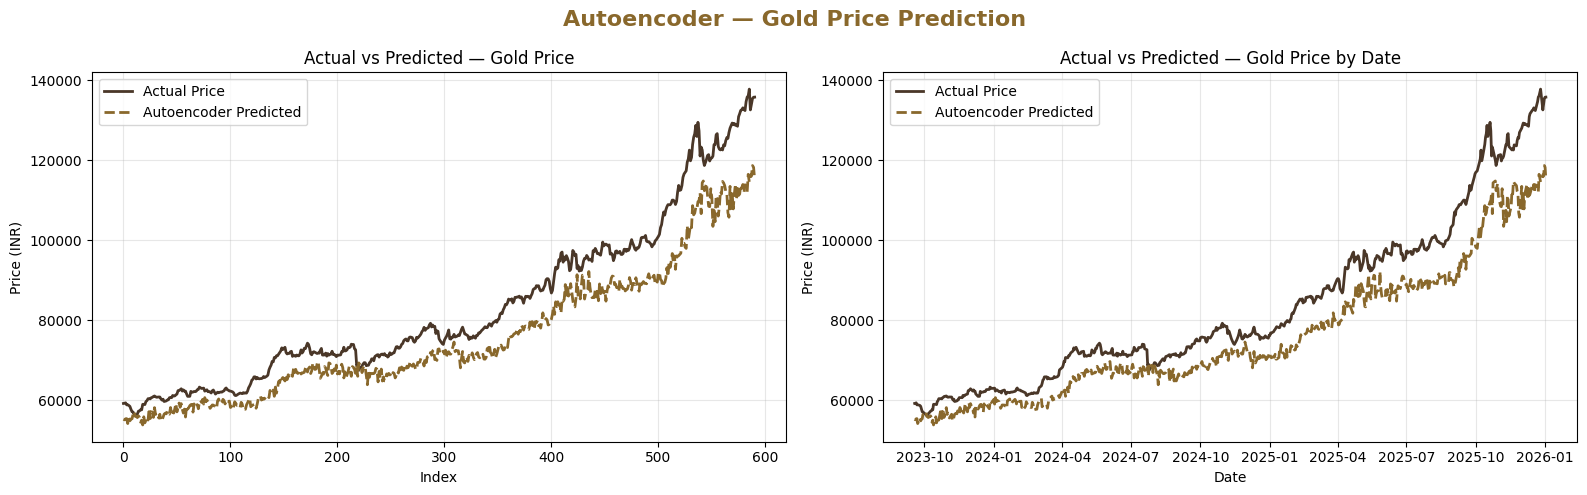

In [79]:
# visualize prediction quality
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Autoencoder — Gold Price Prediction', fontsize=16, fontweight='bold', color='#89682c')

axes[0].plot(y_test_actual, color='#4a3728', linewidth=2, label='Actual Price')
axes[0].plot(ae_pred,       color='#89682c', linewidth=2, linestyle='--', label='Autoencoder Predicted')
axes[0].set_title('Actual vs Predicted — Gold Price')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Price (INR)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

test_dates = df['Date'].iloc[-len(y_test_actual):]
axes[1].plot(test_dates, y_test_actual, color='#4a3728', linewidth=2, label='Actual Price')
axes[1].plot(test_dates, ae_pred,       color='#89682c', linewidth=2, linestyle='--', label='Autoencoder Predicted')
axes[1].set_title('Actual vs Predicted — Gold Price by Date')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (INR)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Model 9: Hybrid models CNN + LSTM

In [52]:
# Model 9: Hybrid CNN + LSTM
from tensorflow.keras.layers import Conv1D, MaxPooling1D

hybrid_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2, strides=2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
hybrid_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
hybrid_model.summary()
print(hybrid_model.output_shape)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 30, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,353 (142.00 KB)

 Trainable params: 36,353 (142.00 KB)

 Non-trainable params: 0 (0.00 B)

(None, 1)


In [53]:
# fit the model on the training sequences
history_hybrid = hybrid_model.fit(
    X_train_seq, y_train_seq,
    epochs=50, batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop], verbose=1
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0130 - mae: 0.0643 - val_loss: 0.1788 - val_mae: 0.3122
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - mae: 0.0302 - val_loss: 0.1631 - val_mae: 0.2965
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - mae: 0.0287 - val_loss: 0.1423 - val_mae: 0.2763
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - mae: 0.0265 - val_loss: 0.0914 - val_mae: 0.2070
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - mae: 0.0242 - val_loss: 0.1351 - val_mae: 0.2834
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0011 - mae: 0.0233 - val_loss: 0.0665 - val_mae: 0.1763
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.9215e-04 - mae: 0.0220 - val_loss: 0.0867 - val_mae: 0.2304
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.4945e-04 - mae: 0.0214 - val_loss: 0.0620 - val_mae: 0.1806
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - los

In [54]:
# generate predictions, inverse transform to original price scale, and evaluate
loss_hybrid, mae_hybrid = hybrid_model.evaluate(X_test_seq, y_test_seq)
print(f"Test Loss : {loss_hybrid:.6f}")
print(f"Test MAE  : {mae_hybrid:.6f}")

hybrid_pred_scaled = hybrid_model.predict(X_test_seq)
hybrid_pred        = inverse_transform_predictions(hybrid_pred_scaled, scaler, n_features)
hybrid_results     = evaluate_model(y_test_actual, hybrid_pred, "CNN + LSTM (Hybrid)")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1788 - mae: 0.3122
Test Loss : 0.178760
Test MAE  : 0.312213
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
CNN + LSTM (Hybrid) Performance Metrics:
MAE  : 11594.9819
RMSE : 15701.9407
R2   : 0.4089
MAPE : 12.03%


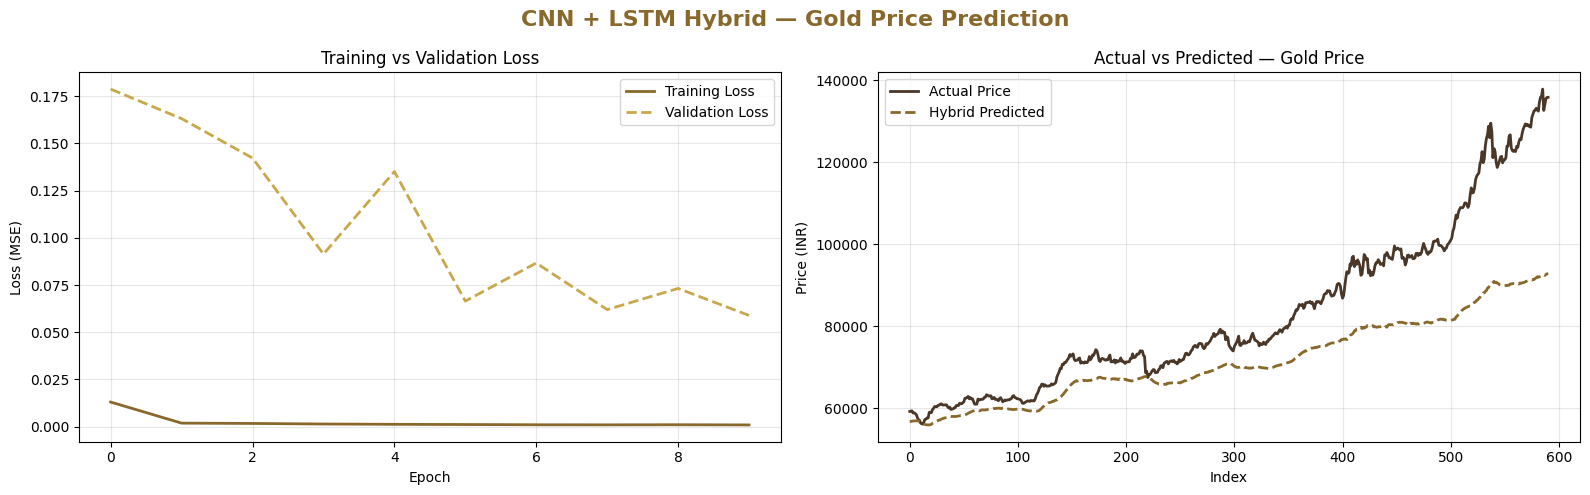

In [78]:
# visualize training dynamics and prediction quality
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('CNN + LSTM Hybrid — Gold Price Prediction', fontsize=16, fontweight='bold', color='#89682c')

axes[0].plot(history_hybrid.history['loss'],     color='#89682c', linewidth=2, label='Training Loss')
axes[0].plot(history_hybrid.history['val_loss'], color='#c9a84c', linewidth=2, linestyle='--', label='Validation Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_test_actual, color='#4a3728', linewidth=2, label='Actual Price')
axes[1].plot(hybrid_pred,   color='#89682c', linewidth=2, linestyle='--', label='Hybrid Predicted')
axes[1].set_title('Actual vs Predicted — Gold Price')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Price (INR)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

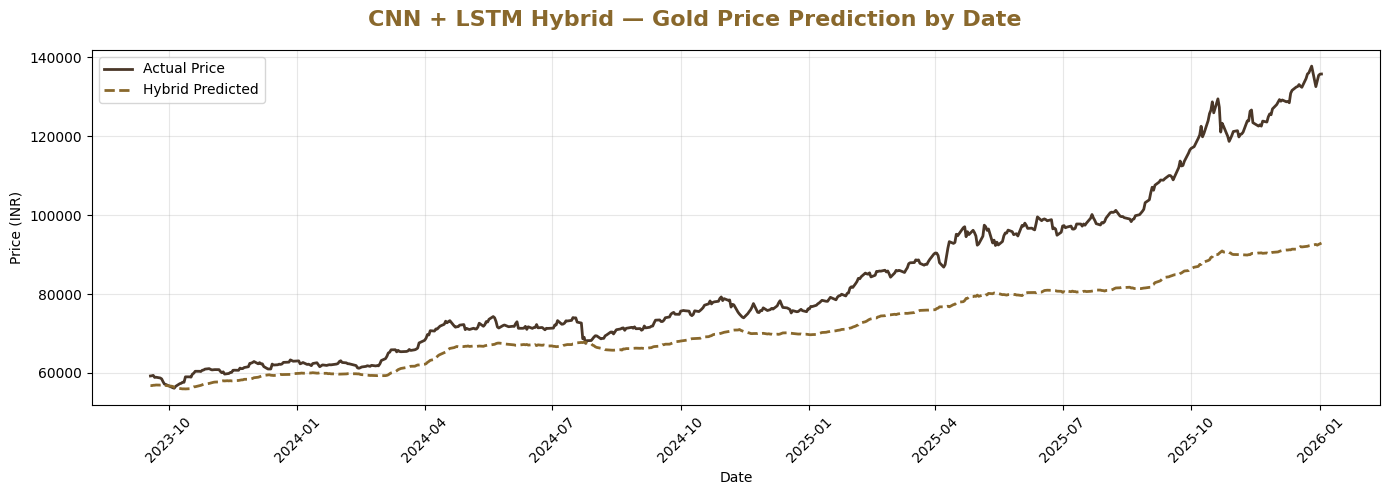

In [77]:
# visualize predictions against real dates
test_dates = df['Date'].iloc[-len(y_test_actual):]

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('CNN + LSTM Hybrid — Gold Price Prediction by Date', fontsize=16, fontweight='bold', color='#89682c')

ax.plot(test_dates, y_test_actual, color='#4a3728', linewidth=2, label='Actual Price')
ax.plot(test_dates, hybrid_pred,   color='#89682c', linewidth=2, linestyle='--', label='Hybrid Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Price (INR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## VI. Compare Final Test Results

### Metrics Comparison

In [57]:
results_df = pd.DataFrame([
    lr_results,
    ann_results,
    gru_results,
    bigru_results,
    lstm_results,
    bilstm_results,
    cnn_results,
    ae_results,
    hybrid_results
])

results_df = results_df.sort_values(by='RMSE')
results_df

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,611.724676,916.937587,0.997984,0.695413
6,CNN,4046.738123,5316.544918,0.932234,4.410764
2,GRU,3461.110170,5573.792083,0.925517,3.372426
3,Bi-GRU,5898.991928,8168.669983,0.840023,6.131329
7,Autoencoder,7439.782312,8777.582741,0.815284,8.362426
1,ANN,8543.702667,9150.940562,0.799236,10.334945
8,CNN + LSTM (Hybrid),11594.981867,15701.940707,0.408899,12.031363
5,Bi-LSTM,16692.537422,23367.401230,-0.309109,16.928573
4,LSTM,17140.176497,24395.161911,-0.426797,17.252021


### Plot Actual vs Predicted

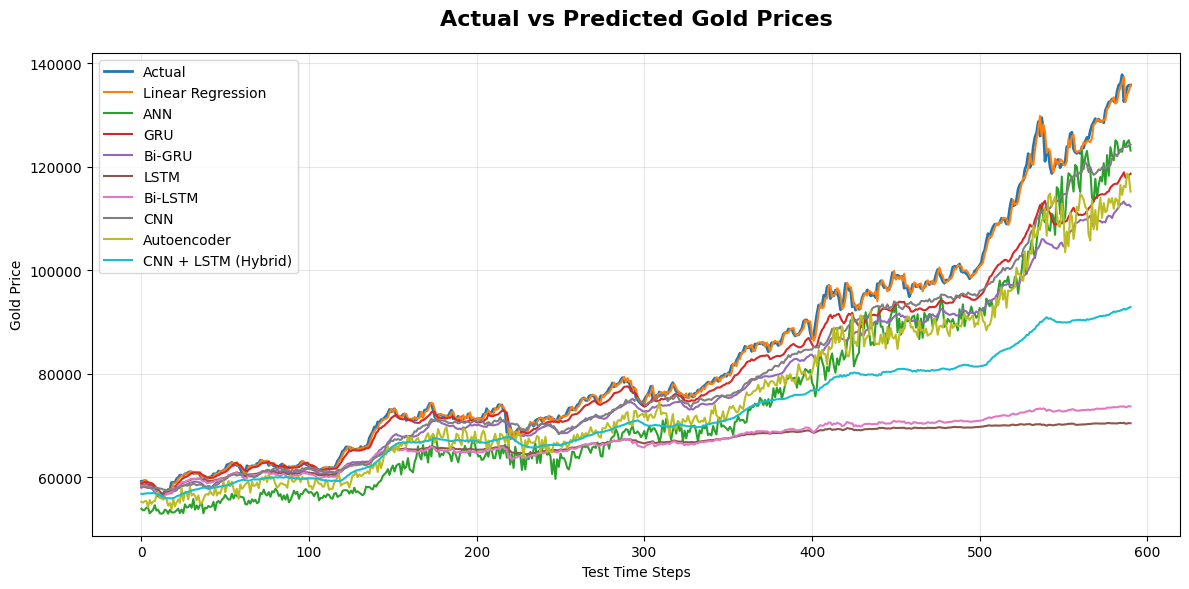

In [58]:
# Based on the sequence index of predictions
plt.figure(figsize=(12, 6))

plt.plot(y_test_actual, label='Actual', linewidth=2)
plt.plot(lr_pred, label='Linear Regression')
plt.plot(ann_pred, label='ANN')
plt.plot(gru_pred, label='GRU')
plt.plot(bigru_pred, label='Bi-GRU')
plt.plot(lstm_pred, label='LSTM')
plt.plot(bilstm_pred, label='Bi-LSTM')
plt.plot(cnn_pred, label='CNN')
plt.plot(ae_pred, label='Autoencoder')
plt.plot(hybrid_pred, label='CNN + LSTM (Hybrid)')

plt.title("Actual vs Predicted Gold Prices", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Test Time Steps")
plt.ylabel("Gold Price")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

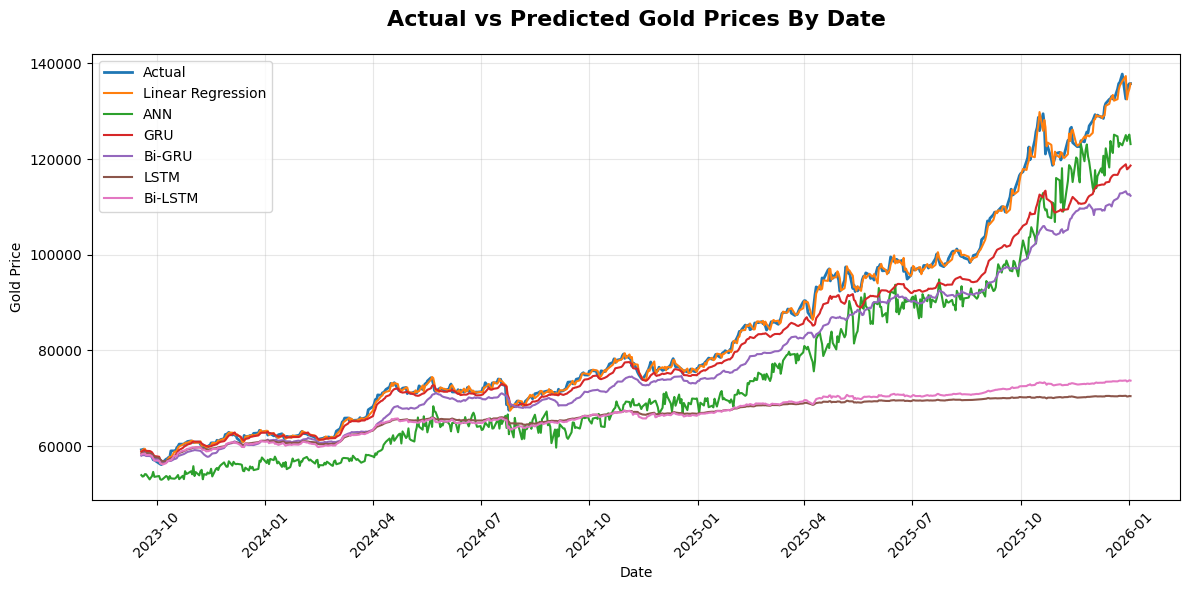

In [59]:
# Real Date Prediction
test_dates = df['Date'].iloc[-len(y_test_actual):]

plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test_actual, label='Actual', linewidth=2)
plt.plot(test_dates, lr_pred, label='Linear Regression')
plt.plot(test_dates, ann_pred, label='ANN')
plt.plot(test_dates, gru_pred, label='GRU')
plt.plot(test_dates, bigru_pred, label='Bi-GRU')
plt.plot(test_dates, lstm_pred, label='LSTM')
plt.plot(test_dates, bilstm_pred, label='Bi-LSTM')

plt.title("Actual vs Predicted Gold Prices By Date", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Plot Model Comparison by RMSE

/tmp/ipykernel_32215/3139289204.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')


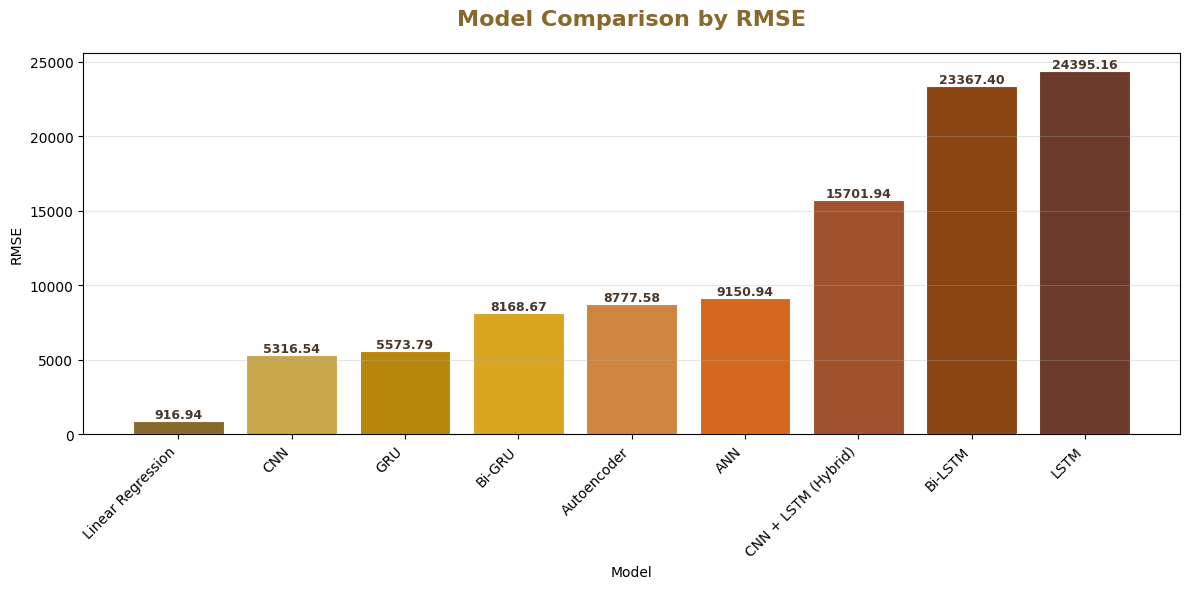

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    results_df['Model'], results_df['RMSE'],
    color=['#89682c', '#c9a84c', '#b8860b', '#daa520',
           '#cd853f', '#d2691e', '#a0522d', '#8b4513', '#6b3a2a'],
    edgecolor='white', linewidth=0.8
)

# add value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom',
        fontsize=9, color='#4a3728', fontweight='bold'
    )

ax.set_title("Model Comparison by RMSE", fontsize=16, fontweight='bold', color='#89682c', pad=20)
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Training Loss

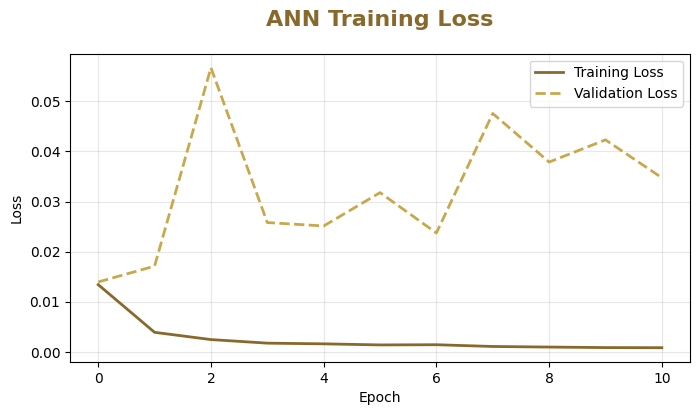

In [65]:
# Plot ANN Training Loss
plt.figure(figsize=(8, 4))
plt.plot(history_ann.history['loss'],    color='#89682c', linewidth=2, label='Training Loss')
plt.plot(history_ann.history['val_loss'], color='#c9a84c', linewidth=2, linestyle='--', label='Validation Loss')
plt.title("ANN Training Loss", fontsize=16, fontweight='bold', color='#89682c', pad=20)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

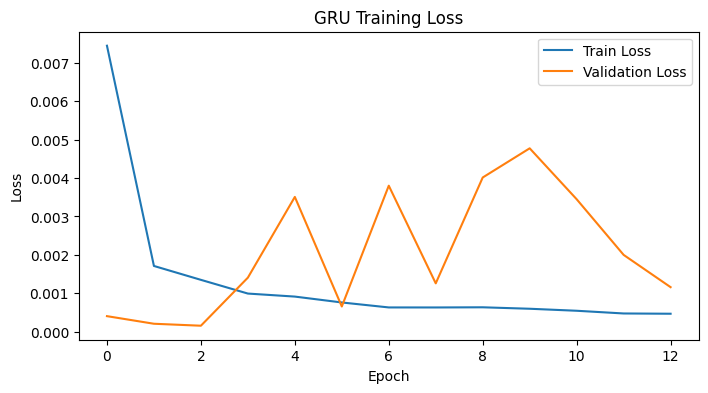

In [62]:
# Plot GRU Training Loss
plt.figure(figsize=(8, 4))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

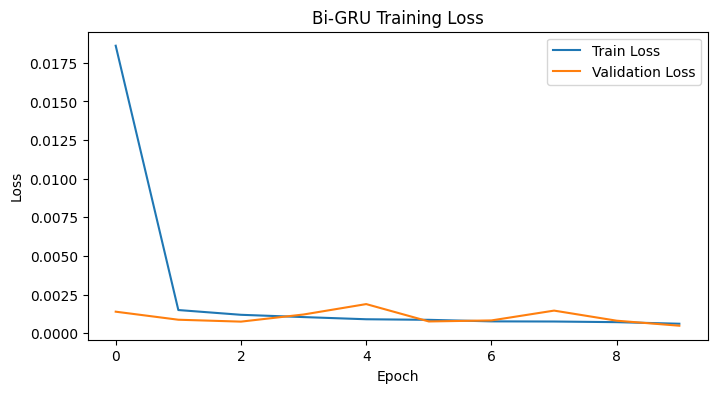

In [63]:
# Plot Bi-GRU Training Loss
plt.figure(figsize=(8, 4))
plt.plot(history_bigru.history['loss'], label='Train Loss')
plt.plot(history_bigru.history['val_loss'], label='Validation Loss')
plt.title("Bi-GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [74]:
def plot_all_losses(histories):
    n = len(histories)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = axes.flatten()

    for i, (name, history) in enumerate(histories.items()):
        axes[i].plot(history.history['loss'], color='#89682c', linewidth=2, label='Training Loss')

        if 'val_loss' in history.history:
            axes[i].plot(history.history['val_loss'], color='#c9a84c', linewidth=2, linestyle='--', label='Validation Loss')

        axes[i].set_title(name)
        axes[i].set_xlabel("Epochs")
        axes[i].set_ylabel("Loss")
        axes[i].legend()
        axes[i].grid(alpha=0.3)

    # Hide empty plots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

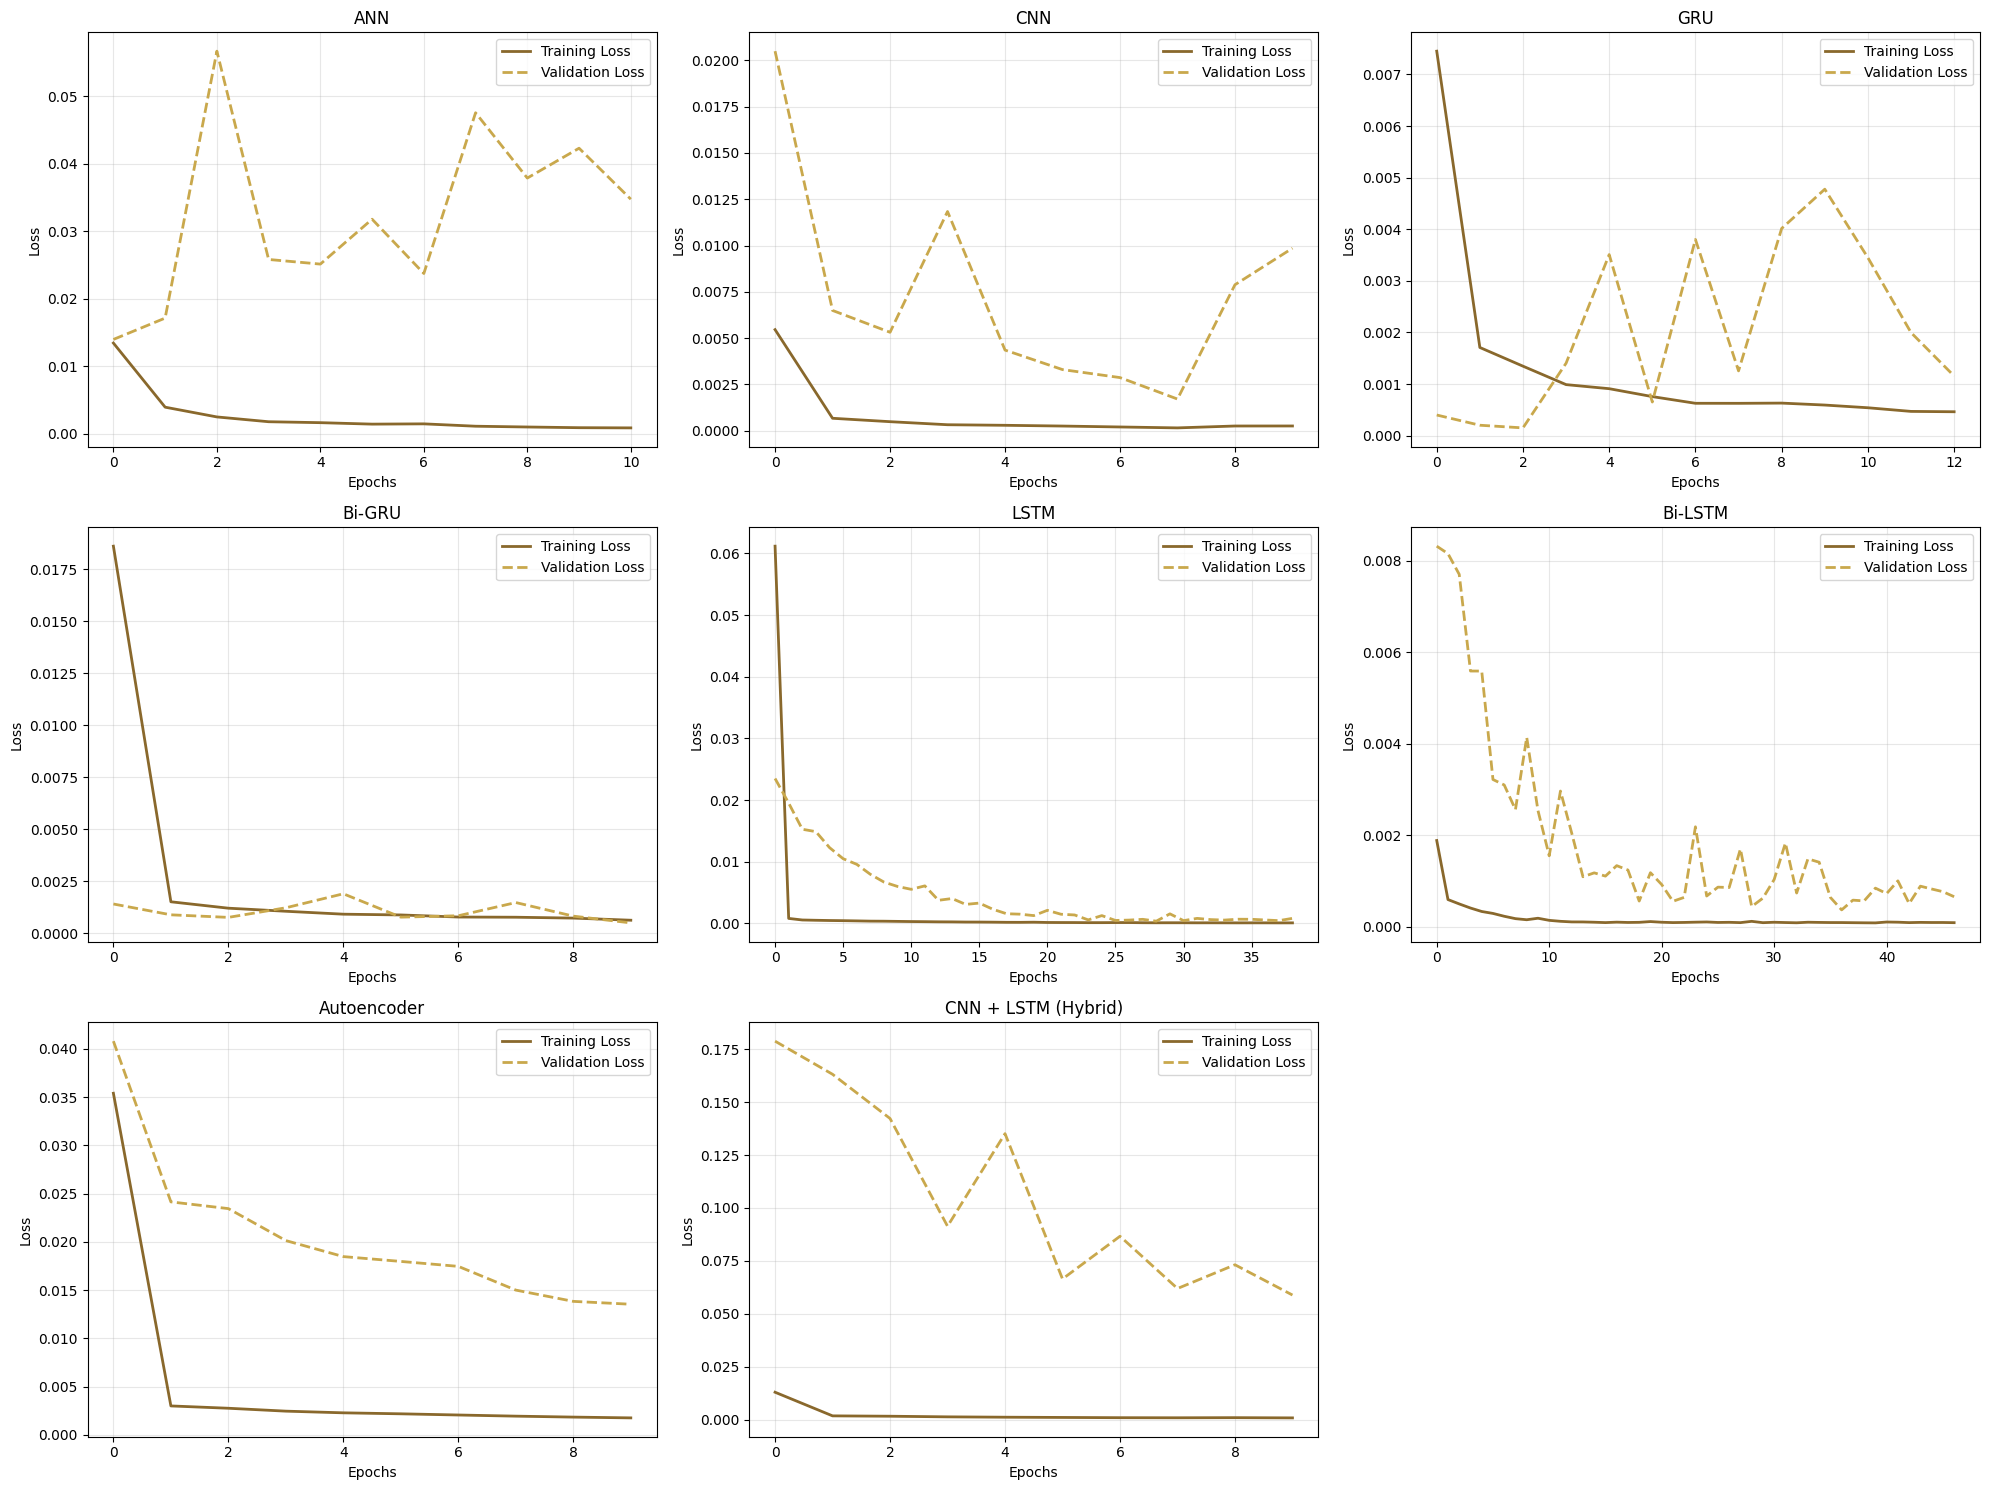

In [75]:
histories = {
    "ANN": history_ann,
    "CNN": history_cnn,
    "GRU": history_gru,
    "Bi-GRU": history_bigru,
    "LSTM": history_lstm,
    "Bi-LSTM": history_bilstm,
    "CNN": history_cnn,
    "Autoencoder": history_ae,
    "CNN + LSTM (Hybrid)": history_hybrid

}

plot_all_losses(histories)